## Project -> Linear Regression: Car Sales 

#### 1. Import Libraries

In [2]:
import numpy as np
import pandas as pd
import statsmodels.api as sm 
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import seaborn as sns
sns.set()

#### 2. Load Data

In [ ]:
df = pd.read_csv('')
df.head()

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
0,BMW,4200.0,sedan,277,2.0,Petrol,yes,1991,320
1,Mercedes-Benz,7900.0,van,427,2.9,Diesel,yes,1999,Sprinter 212
2,Mercedes-Benz,13300.0,sedan,358,5.0,Gas,yes,2003,S 500
3,Audi,23000.0,crossover,240,4.2,Petrol,yes,2007,Q7
4,Toyota,18300.0,crossover,120,2.0,Petrol,yes,2011,Rav 4


##### Assumptions
- BMW is more expensive than a Toyota.
- More mileage then it should be cheaper than less mileage cars
- Sports cars have larger engine(EngineV) than economy cars
- The older(Year) the car the cheaper it should be.

#### 3. Preprocessing

##### 3.1 Exploring the descriptive statistics of the variables

In [4]:
df.describe(include = 'all')

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
count,4345,4173.000000,4345,4345.000000,4195.000000,4345,4345,4345.000000,4345
unique,7,NaN,6,NaN,NaN,4,2,NaN,312
top,Volkswagen,NaN,sedan,NaN,NaN,Diesel,yes,NaN,E-Class
freq,936,NaN,1649,NaN,NaN,2019,3947,NaN,199
mean,NaN,19418.746935,NaN,161.237284,2.790734,NaN,NaN,2006.550058,NaN
std,NaN,25584.242620,NaN,105.705797,5.066437,NaN,NaN,6.719097,NaN
min,NaN,600.000000,NaN,0.000000,0.600000,NaN,NaN,1969.000000,NaN
25%,NaN,6999.000000,NaN,86.000000,1.800000,NaN,NaN,2003.000000,NaN
50%,NaN,11500.000000,NaN,155.000000,2.200000,NaN,NaN,2008.000000,NaN
75%,NaN,21700.000000,NaN,230.000000,3.000000,NaN,NaN,2012.000000,NaN


**In .describe() you'll only get descriptives values(numerical variables) by default, to add categorical values too, use (include = 'all) and that will give you values for the whole dataset**

##### Assumptions
- Count -> Each variable have different observations which implies there are some missing values.
- Unique -> There are 312 models, really hard to implement at a regressio.

#### 3.2 Determining the variables of interest

In [5]:
data = df.drop(['Model'], axis=1) # axis 0 means rows and 1 means columns
data.describe(include = 'all')

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year
count,4345,4173.000000,4345,4345.000000,4195.000000,4345,4345,4345.000000
unique,7,NaN,6,NaN,NaN,4,2,NaN
top,Volkswagen,NaN,sedan,NaN,NaN,Diesel,yes,NaN
freq,936,NaN,1649,NaN,NaN,2019,3947,NaN
mean,NaN,19418.746935,NaN,161.237284,2.790734,NaN,NaN,2006.550058
std,NaN,25584.242620,NaN,105.705797,5.066437,NaN,NaN,6.719097
min,NaN,600.000000,NaN,0.000000,0.600000,NaN,NaN,1969.000000
25%,NaN,6999.000000,NaN,86.000000,1.800000,NaN,NaN,2003.000000
50%,NaN,11500.000000,NaN,155.000000,2.200000,NaN,NaN,2008.000000
75%,NaN,21700.000000,NaN,230.000000,3.000000,NaN,NaN,2012.000000


##### Assumptions
- Price & EngineV might have missing values

#### 3.3 Dealing with missing values

In [6]:
data.isnull().sum()

Brand             0
Price           172
Body              0
Mileage           0
EngineV         150
Engine Type       0
Registration      0
Year              0
dtype: int64

**I'll be dropping null values from Price & EngineV**

In [7]:
data_no_mv = data.dropna(axis=0)
data_no_mv.describe(include='all')

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year
count,4025,4025.000000,4025,4025.000000,4025.000000,4025,4025,4025.000000
unique,7,NaN,6,NaN,NaN,4,2,NaN
top,Volkswagen,NaN,sedan,NaN,NaN,Diesel,yes,NaN
freq,880,NaN,1534,NaN,NaN,1861,3654,NaN
mean,NaN,19552.308065,NaN,163.572174,2.764586,NaN,NaN,2006.379627
std,NaN,25815.734988,NaN,103.394703,4.935941,NaN,NaN,6.695595
min,NaN,600.000000,NaN,0.000000,0.600000,NaN,NaN,1969.000000
25%,NaN,6999.000000,NaN,90.000000,1.800000,NaN,NaN,2003.000000
50%,NaN,11500.000000,NaN,158.000000,2.200000,NaN,NaN,2007.000000
75%,NaN,21900.000000,NaN,230.000000,3.000000,NaN,NaN,2012.000000


##### 3.4 Exploring the PDFs

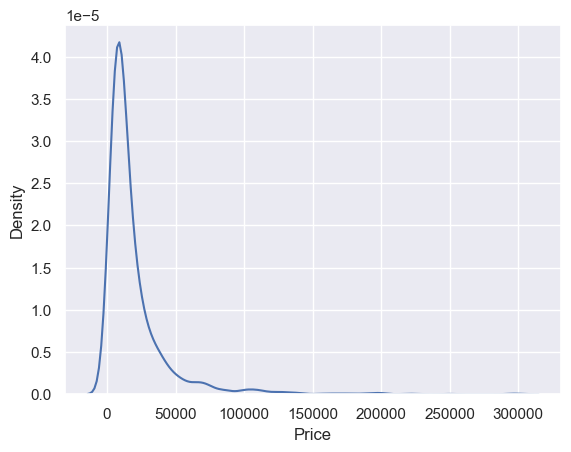

In [8]:
sns.kdeplot(data_no_mv['Price'])
plt.show()

**I am looking for normal distribution for optimal results. Price column has exponential values, this would be an issue for the regression. Upon checking Price columns stats, there may be Outliers in that column. Observations that lie on abnormal distance from other observations in the data. Car's coefficient will be inflated as the regression will try to place the line closer to those values. To deal with that I'll remove top 1% of observations**

##### 3.5 Dealing with Outliers

In [9]:
q = data_no_mv['Price'].quantile(0.99)
data_1 = data_no_mv[data_no_mv['Price']<q]
data_1.describe(include='all')

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year
count,3984,3984.000000,3984,3984.000000,3984.000000,3984,3984,3984.000000
unique,7,NaN,6,NaN,NaN,4,2,NaN
top,Volkswagen,NaN,sedan,NaN,NaN,Diesel,yes,NaN
freq,880,NaN,1528,NaN,NaN,1853,3613,NaN
mean,NaN,17837.117460,NaN,165.116466,2.743770,NaN,NaN,2006.292922
std,NaN,18976.268315,NaN,102.766126,4.956057,NaN,NaN,6.672745
min,NaN,600.000000,NaN,0.000000,0.600000,NaN,NaN,1969.000000
25%,NaN,6980.000000,NaN,93.000000,1.800000,NaN,NaN,2002.750000
50%,NaN,11400.000000,NaN,160.000000,2.200000,NaN,NaN,2007.000000
75%,NaN,21000.000000,NaN,230.000000,3.000000,NaN,NaN,2011.000000


**The maximum value reduced from 300000 to 129222 and mean has also reduced, though the max value is far from mean, it is a acceptably closer value. Now I'll check the plot again.**

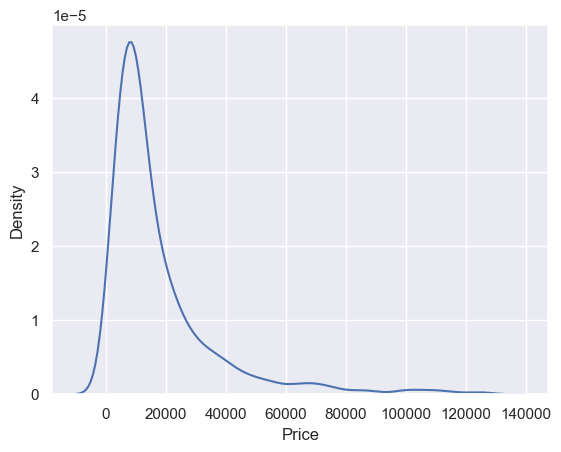

In [10]:
sns.kdeplot(data_1['Price'])
plt.show()

**You'll see(👀) a change in the distribution of the new and updated Price column.**

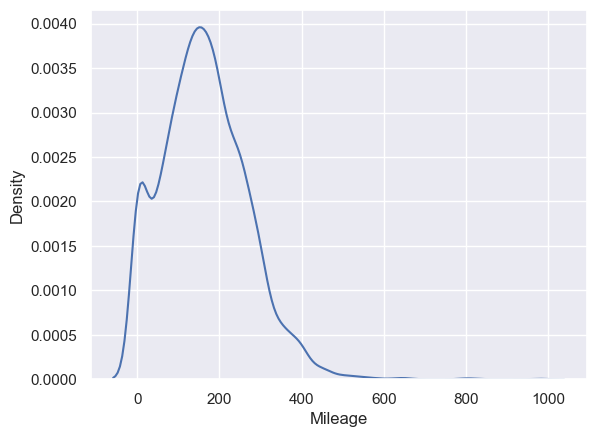

In [11]:
sns.kdeplot(data_no_mv['Mileage'])
plt.show()

In [12]:
q = data_1['Mileage'].quantile(0.99)
data_2 = data_1[data_1['Mileage']<q]

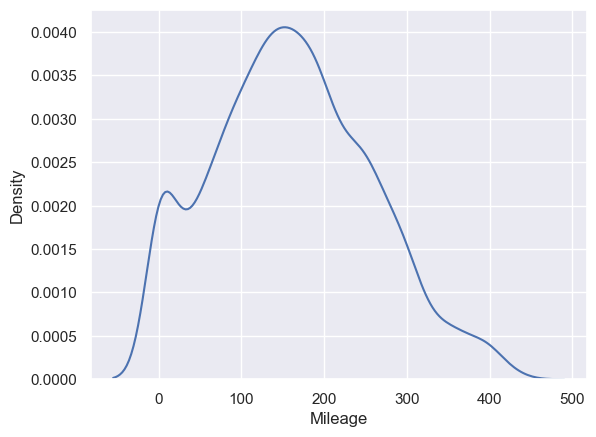

In [13]:
sns.kdeplot(data_2['Mileage'])
plt.show()

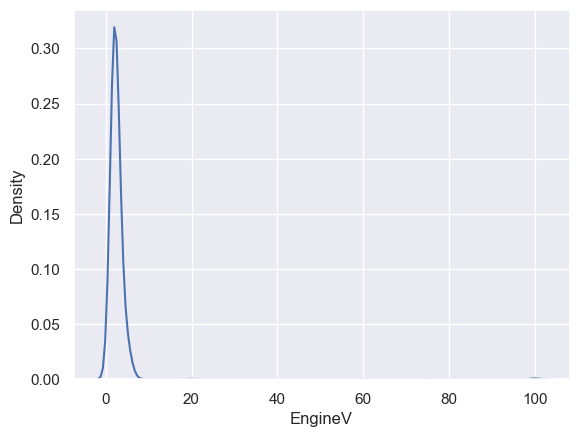

In [14]:
sns.kdeplot(data_no_mv['EngineV'])
plt.show()

**EngineV has very high values, not usual values, need to do some basic research on that. A common way to label missing values is by assigning 99.99 . Bad practice to label values in this way as it harder for other user of the data to distinguish them from true values. I'll be removing all values above 6.5 for EngineV column.**

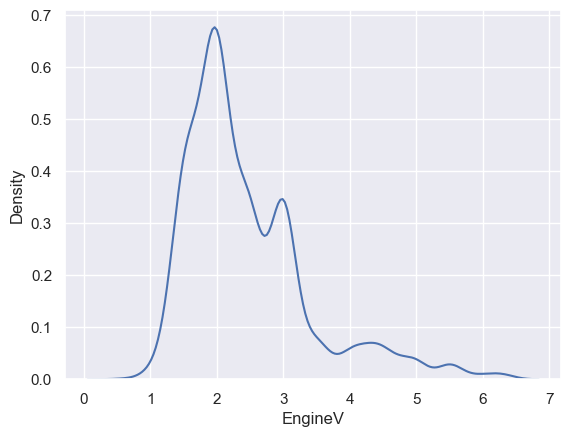

In [15]:
data_3 = data_2[data_2['EngineV']<6.5]
sns.kdeplot(data_3['EngineV'])
plt.show()

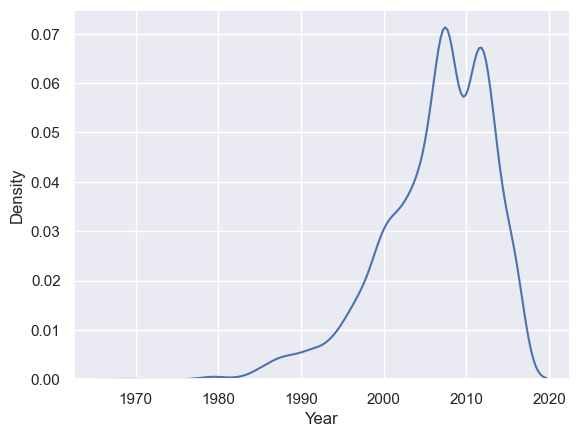

In [16]:
sns.kdeplot(data_3['Year'])
plt.show()

**There are few older cars, so, I'll take out the first percentile and keep all the observations that are higher.**

In [17]:
q1 = data_3['Year'].quantile(0.01)
data_4 = data_3[data_3['Year']>q1]

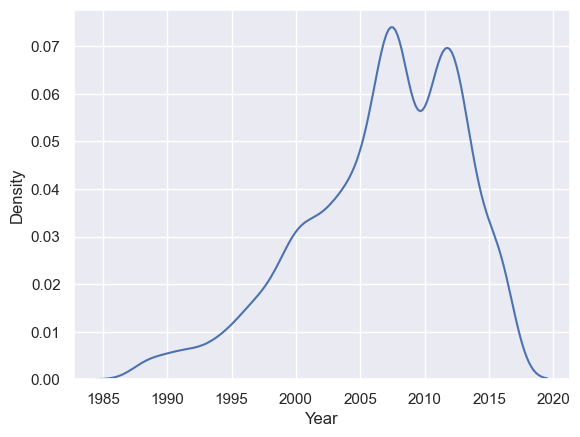

In [18]:
sns.kdeplot(data_4['Year'])
plt.show()

**Now, I'll reset the index for the cleaned data, I have created for further analysis**

In [19]:
data_cleaned = data_4.reset_index(drop=True) # -> Completely forget the old index

In [20]:
data_cleaned.describe(include='all')

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year
count,3867,3867.000000,3867,3867.000000,3867.000000,3867,3867,3867.000000
unique,7,NaN,6,NaN,NaN,4,2,NaN
top,Volkswagen,NaN,sedan,NaN,NaN,Diesel,yes,NaN
freq,848,NaN,1467,NaN,NaN,1807,3505,NaN
mean,NaN,18194.455679,NaN,160.542539,2.450440,NaN,NaN,2006.709853
std,NaN,19085.855165,NaN,95.633291,0.949366,NaN,NaN,6.103870
min,NaN,800.000000,NaN,0.000000,0.600000,NaN,NaN,1988.000000
25%,NaN,7200.000000,NaN,91.000000,1.800000,NaN,NaN,2003.000000
50%,NaN,11700.000000,NaN,157.000000,2.200000,NaN,NaN,2008.000000
75%,NaN,21700.000000,NaN,225.000000,3.000000,NaN,NaN,2012.000000


**I have cleaned out 250 observations....👍**

#### 4. Checking the OLS assumptions

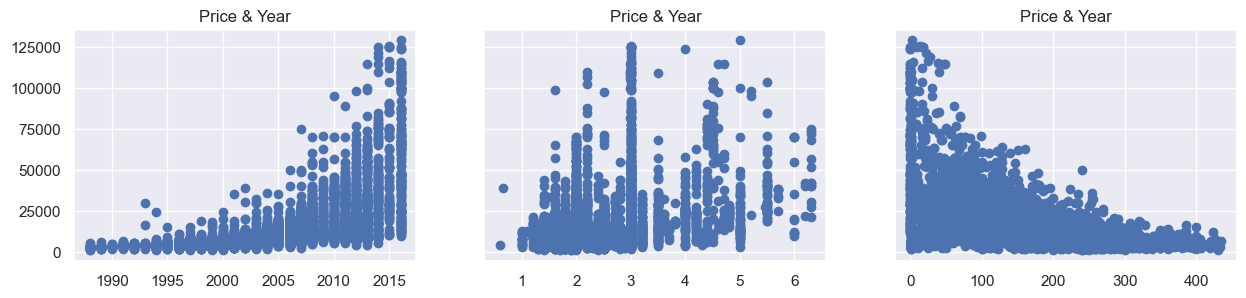

In [21]:
f, (ax1, ax2, ax3) = plt.subplots(1,3, sharey=True, figsize= (15,3))
ax1.scatter(data_cleaned['Year'],data_cleaned['Price'])
ax1.set_title('Price & Year')
ax2.scatter(data_cleaned['EngineV'],data_cleaned['Price'])
ax2.set_title('Price & Year')
ax3.scatter(data_cleaned['Mileage'],data_cleaned['Price'])
ax3.set_title('Price & Year')
plt.show()

**Log transformations are expecially useful when facing exponential relationships.**

##### 4.1 Relaxing the assumptions

In [22]:
log_price = np.log(data_cleaned['Price'])
data_cleaned['log_price'] = log_price
data_cleaned

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,log_price
0,BMW,4200.0,sedan,277,2.0,Petrol,yes,1991,8.342840
1,Mercedes-Benz,7900.0,van,427,2.9,Diesel,yes,1999,8.974618
2,Mercedes-Benz,13300.0,sedan,358,5.0,Gas,yes,2003,9.495519
3,Audi,23000.0,crossover,240,4.2,Petrol,yes,2007,10.043249
4,Toyota,18300.0,crossover,120,2.0,Petrol,yes,2011,9.814656
...,...,...,...,...,...,...,...,...,...
3862,Volkswagen,11500.0,van,163,2.5,Diesel,yes,2008,9.350102
3863,Toyota,17900.0,sedan,35,1.6,Petrol,yes,2014,9.792556
3864,Mercedes-Benz,125000.0,sedan,9,3.0,Diesel,yes,2014,11.736069
3865,BMW,6500.0,sedan,1,3.5,Petrol,yes,1999,8.779557


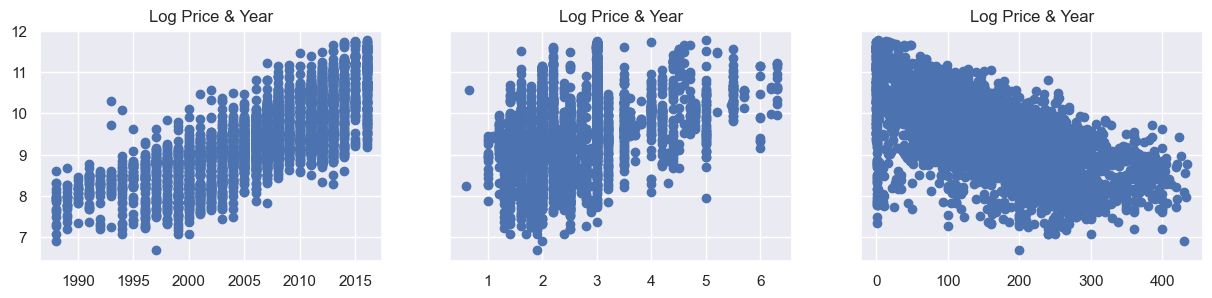

In [23]:
f, (ax1, ax2, ax3) = plt.subplots(1,3, sharey=True, figsize= (15,3))

ax1.scatter(data_cleaned['Year'],data_cleaned['log_price'])
ax1.set_title('Log Price & Year')
ax2.scatter(data_cleaned['EngineV'],data_cleaned['log_price'])
ax2.set_title('Log Price & Year')
ax3.scatter(data_cleaned['Mileage'],data_cleaned['log_price'])
ax3.set_title('Log Price & Year')

plt.show()

In [24]:
data_cleaned = data_cleaned.drop(['Price'], axis=1)

**Droping the Price column as there is no need for it anymore, since log_price better supports the goal.**

##### 4.2 Multicollinearity

In [25]:
data_cleaned.columns.values

<ArrowStringArray>
[       'Brand',         'Body',      'Mileage',      'EngineV',
  'Engine Type', 'Registration',         'Year',    'log_price']
Length: 8, dtype: str

**From above columns I can use that Year and Mileage will be correlated. The newer the car, the lower its mileage. Therefore I can assume there's some level of multicollinearity in the data.**

*Multicollinearity* occurs when two or more independent variables in a statistical or machine learning model are highly correlated with each other.

**One of the best ways to check multicollinearity is through VIF. (variance inflation factor) It produces the measure which estimates how much larger the root of standard error of an estimate is, compared to a situation where the variable was completely uncorrelated with other predictors.**

In [26]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
variables = data_cleaned[['Mileage', 'Year', 'EngineV']]
vif = pd.DataFrame()
vif['VIF'] = [variance_inflation_factor(variables.values, i) for i in range(variables.shape[1])]
vif['features'] = variables.columns
print(round(vif, 4))

       VIF features
0   3.7916  Mileage
1  10.3549     Year
2   7.6621  EngineV


##### VIF Score
- If VIF is 1 or less than 1; means, no multicollinearity
- If between 1 and 5 is perfectly OK
- If above 5 or 6 then it is unacceptable
- --
So, I'll remove Year from  multicollinearity table created above.

In [27]:
data_no_multicollinearity = data_cleaned.drop(['Year'], axis = 1)

#### 5. Create Dummy Variables

In [28]:
data_with_dummies = pd.get_dummies(data_no_multicollinearity, drop_first = True)
data_with_dummies.head()

,Mileage,EngineV,log_price,Brand_BMW,Brand_Mercedes-Benz,Brand_Mitsubishi,Brand_Renault,Brand_Toyota,Brand_Volkswagen,Body_hatch,Body_other,Body_sedan,Body_vagon,Body_van,Engine Type_Gas,Engine Type_Other,Engine Type_Petrol,Registration_yes
0,277,2.0,8.342840,True,False,False,False,False,False,False,False,True,False,False,False,False,True,True
1,427,2.9,8.974618,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True
2,358,5.0,9.495519,False,True,False,False,False,False,False,False,True,False,False,True,False,False,True
3,240,4.2,10.043249,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True
4,120,2.0,9.814656,False,False,False,False,True,False,False,False,False,False,False,False,False,True,True


##### 5.1 Rearrange column

In [29]:
#data_with_dummies.columns.values

In [30]:
cols = ['log_price',           'Mileage',             'EngineV',           
           'Brand_BMW', 'Brand_Mercedes-Benz',    'Brand_Mitsubishi',
        'Brand_Renault',        'Brand_Toyota',    'Brand_Volkswagen',
          'Body_hatch',          'Body_other',          'Body_sedan',
          'Body_vagon',            'Body_van',     'Engine Type_Gas',
        'Engine Type_Other',  'Engine Type_Petrol',    'Registration_yes'
]

In [31]:
data_preprocessed = data_with_dummies[cols]
data_preprocessed.head()

,log_price,Mileage,EngineV,Brand_BMW,Brand_Mercedes-Benz,Brand_Mitsubishi,Brand_Renault,Brand_Toyota,Brand_Volkswagen,Body_hatch,Body_other,Body_sedan,Body_vagon,Body_van,Engine Type_Gas,Engine Type_Other,Engine Type_Petrol,Registration_yes
0,8.342840,277,2.0,True,False,False,False,False,False,False,False,True,False,False,False,False,True,True
1,8.974618,427,2.9,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True
2,9.495519,358,5.0,False,True,False,False,False,False,False,False,True,False,False,True,False,False,True
3,10.043249,240,4.2,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True
4,9.814656,120,2.0,False,False,False,False,True,False,False,False,False,False,False,False,False,True,True


#### 6. Linear Regression Model

##### 6.1 Declare the inputs and targets

In [32]:
targets = data_preprocessed['log_price']
inputs = data_preprocessed.drop(['log_price'], axis = 1)

##### 6.2 Scale the data

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(inputs)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


**We must fit the inputs using .fit() method**

In [34]:
inputs_scaled = scaler.transform(inputs)

**Here we use the transform methods to get the standardized inputs.**

##### 6.3 Train Test Split

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(inputs_scaled, targets, test_size = 0.2, random_state = 42)

##### 6.4 Create Regression

In [36]:
reg = LinearRegression()
reg.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


**This is not a Linear but a Log Linear Regression because we are using a dependent variable, which is logarith of price.**

**A simple way to check the final result is to plot the predicted values with observed values.**

In [37]:
y_hat = reg.predict(X_train)

**The predictions of the linear model are labeled with Y_hat** 

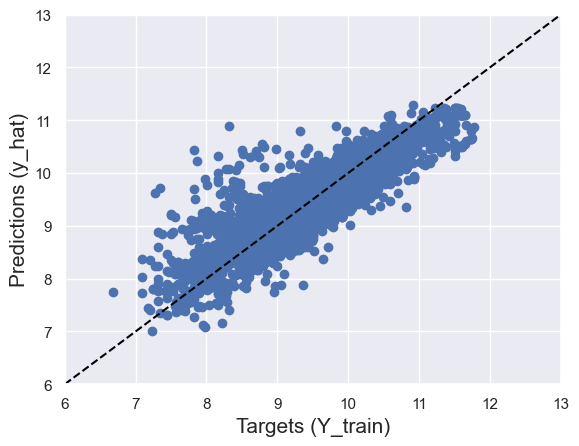

In [49]:
plt.scatter(Y_train, y_hat) # targets and predictions
plt.xlabel('Targets (Y_train)', size = 15)
plt.ylabel('Predictions (y_hat)', size = 15)
plt.plot([6, 13], [6, 13], color="black", linestyle="--", label="45° line")
plt.xlim(6, 13)
plt.ylim(6, 13)
plt.show()

**Draw a 45 degree line, the closer the scatter plot to this line the better the model. This model is not perfect but not random either.**

- **Residual = Difference between the targets and the predictions.**
- **A residual plot refers to the distibution of the residuals**

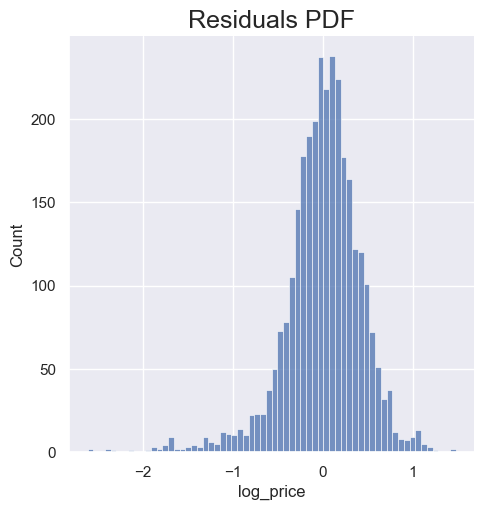

In [51]:
sns.displot(Y_train - y_hat)
plt.title("Residuals PDF", size = 18)
plt.show()

**From the regression assumptions:
- we know that error must be normally distributed.
- with a mean of zero. 
- The residuals are the estimates of the errors, so we would expect the same from them. 
- The result looks quite normal, in the sense of normally distributed. The mean seems to be zero too.
- Issue -> Much longer tail on the negative side. Meaning, certain observations difference between the targets and the predictions is much lower than the mean.
    - This implies that those predictions over estimates the targets.
    - We don't see that on the right, which means prediction really under estimates the targets.

##### 6.4 R_squared

In [53]:
r_squared = reg.score(X_train, Y_train)
print(round(r_squared, 3))

0.755


##### 6.5 Finding Weights & Bias

In [59]:
weight = reg.coef_
print(weight)

[-0.46815598  0.21526817  0.01105151  0.00569157 -0.14247174 -0.18769337
 -0.06529696 -0.09898873 -0.13980763 -0.09384461 -0.17892753 -0.11457574
 -0.15668036 -0.11685263 -0.02572253 -0.15106183  0.31442123]


In [55]:
bias = reg.intercept_
print(round(bias, 3))

9.421


##### 6.6 Create Summary

In [60]:
reg_summary = pd.DataFrame(inputs.columns.values, columns=['Features'])
reg_summary['Weights'] = reg.coef_
reg_summary

,Features,Weights
0,Mileage,-0.468156
1,EngineV,0.215268
2,Brand_BMW,0.011052
3,Brand_Mercedes-Benz,0.005692
4,Brand_Mitsubishi,-0.142472
5,Brand_Renault,-0.187693
6,Brand_Toyota,-0.065297
7,Brand_Volkswagen,-0.098989
8,Body_hatch,-0.139808
9,Body_other,-0.093845


**Weights Interpretation**
- A positive weight shows that as a feature increases in value, so do the log_price & 'Price' respectively.
    - Example -> EngineV, bigger engine volume, higher the price.
- A negative weight shows that as a feature increases in value, log_price & 'Price' decreases.
    - Example -> Mileage increase, price decrease

#### 7. Testing

In [61]:
y_hat_test = reg.predict(X_test)

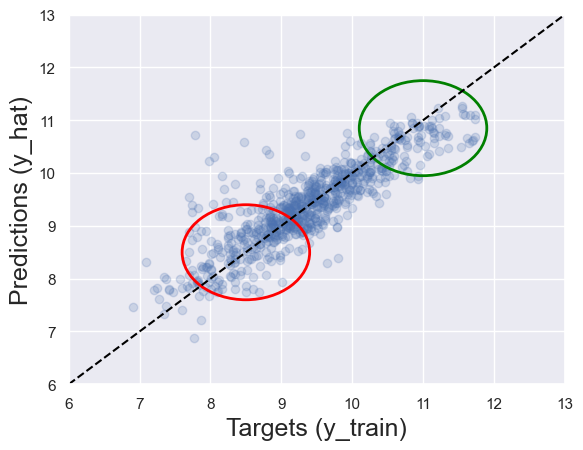

In [118]:
from matplotlib.patches import Circle

plt.scatter(Y_test, y_hat_test, alpha = 0.2)
plt.xlabel('Targets (y_train)', size = 18)
plt.ylabel('Predictions (y_hat)', size = 18)

plt.plot([6, 13], [6, 13], color="black", linestyle="--", label="45° line")

circle_1 = Circle((11, 10.85), radius=0.9, color="green", fill=False, linewidth=2)
plt.gca().add_patch(circle_1)

circle_2 = Circle((8.5, 8.5), radius=0.9, color="red", fill=False, linewidth=2)
plt.gca().add_patch(circle_2)

plt.xlim(6,13)
plt.ylim(6,13)
plt.show()

- **For higher prices we have a higher concentration of values around the 45 degree line.**
- **Model is very good at predicting higher prices but for lower ones situation is not that good, they are much more scattered**

#### 8. New DataFrame to check performance

In [121]:
df_pf = pd.DataFrame(np.exp(y_hat_test), columns=['Predictions'])
df_pf.head()

,Predictions
0,40419.308971
1,7956.895960
2,5757.284408
3,9765.810605
4,7027.363814


**Here we are using np.exp() to convert log_price to Price**

In [122]:
df_pf['Target'] = np.exp(Y_test)
df_pf.head()

,Predictions,Target
0,40419.308971,4200.0
1,7956.895960,NaN
2,5757.284408,NaN
3,9765.810605,NaN
4,7027.363814,NaN


**Lots of missing values and spread quuite randomly.**

In [124]:
Y_test.head()

2174    9.966462
1420    9.093807
2478    8.086410
1584    9.392662
952     8.594154
Name: log_price, dtype: float64

**It contains indexes, when we split the data into train and test, the original indices were preserved. So when we added y_test to df_pf, Pandas try to match indices. So we need to forget this original indexing.** 

In [125]:
Y_test = Y_test.reset_index(drop = True)
Y_test.head()

0    9.966462
1    9.093807
2    8.086410
3    9.392662
4    8.594154
Name: log_price, dtype: float64

- **This wii reset the index of Y_test.** 
- **Now in below cell, we'll overwrite the y_test in df_pf.**

##### Add Target Column

In [126]:
df_pf['Target'] = np.exp(Y_test)
df_pf.head()

,Predictions,Target
0,40419.308971,21300.0
1,7956.895960,8900.0
2,5757.284408,3250.0
3,9765.810605,12000.0
4,7027.363814,5400.0


**Now we have predictions and targets and now we can proceed to comparing them.**

##### Add Residual Column

In [128]:
df_pf['Residuals'] = df_pf['Target'] - df_pf['Predictions']
df_pf.head()

,Predictions,Target,Residuals
0,40419.308971,21300.0,-19119.308971
1,7956.895960,8900.0,943.104040
2,5757.284408,3250.0,-2507.284408
3,9765.810605,12000.0,2234.189395
4,7027.363814,5400.0,-1627.363814


- **OLS minimizes sum of squared error. Lower the error, better the explanatory power.**
- **Examining the result is the same as examinig the heart of the algortithm.**

##### Added Percentage column

In [129]:
df_pf['Difference_in_%'] = np.absolute(df_pf['Residuals'] / df_pf['Target'] * 100)
df_pf.head()

,Predictions,Target,Residuals,Difference_in_%
0,40419.308971,21300.0,-19119.308971,89.762014
1,7956.895960,8900.0,943.104040,10.596675
2,5757.284408,3250.0,-2507.284408,77.147213
3,9765.810605,12000.0,2234.189395,18.618245
4,7027.363814,5400.0,-1627.363814,30.136367


#### Summary

In [130]:
df_pf.describe()

,Predictions,Target,Residuals,Difference_in_%
count,774.000000,774.000000,774.000000,774.000000
mean,16113.011638,17799.988992,1686.977355,42.085282
std,13326.229797,19723.434542,11192.614496,96.169928
min,967.030415,999.000000,-42859.020603,0.020246
25%,7467.591694,6700.000000,-2246.354353,11.024941
50%,11914.358989,11050.000000,-38.697776,24.086183
75%,20249.505640,20475.000000,3004.524837,42.381716
max,79026.348020,125000.000000,81051.158885,1785.792525


In [135]:
pd.options.display.max_rows = 999
pd.set_option('display.float_format', lambda x: '%.2f' % x)
df_pf.sort_values(by=['Difference_in_%']).head(20)

,Predictions,Target,Residuals,Difference_in_%
387,13602.75,13600.00,-2.75,0.02
74,28889.06,28900.00,10.94,0.04
314,35530.21,35500.00,-30.21,0.09
336,11313.27,11300.00,-13.27,0.12
425,2995.68,3000.00,4.32,0.14
262,52180.11,52055.25,-124.86,0.24
674,3107.51,3100.00,-7.51,0.24
648,9675.57,9700.00,24.43,0.25
79,21407.59,21335.00,-72.59,0.34
313,9865.72,9900.00,34.28,0.35


#### How to Improve Model
- Use different set of variables.
- Remove bigger chunk of outliers.
- Use different kind of transformations.
- **ML requires requires us to revisit the model many times before we truly satisfied with the results.**

## Finish..